Project 3: Microstructure Doppelgängers — Similar Summaries, Different Evolution Laws


NAME- KUMARI PRIYA LALA

ROLL NUMBER- MS25MTECH14006

part 1 ANSWERS

What to look for:As you inspect the generated structures, ask:
1.Which family is more interconnected?
>The Cahn–Hilliard family is much more interconnected. Because it models a conserved field (like phase separation in an alloy), mass must be redistributed globally rather than created or destroyed locally. This constraint typically results in a continuous, intertwined network known as a bicontinuous structure .

2.Does one family form more rounded or more tortuous domains?
>Allen–Cahn forms more rounded, isolated domains. It minimizes interfacial energy purely through local curvature reduction (like grain growth or bubble collapse), which naturally drives shapes toward spheres or isolated islands .

>Cahn–Hilliard forms highly tortuous, labyrinth-like domains. The competition between mass conservation and interface minimization stretches and winds the phases around each other.

3.If phase fraction is similar, what still distinguishes the two?
> Their topology and morphology. Even if both microstructures are 45% phase A and 55% phase B, the Cahn–Hilliard structure will likely be a single percolating web, while the Allen–Cahn structure will consist of disjointed, independent blobs. Transport properties (like permeability or conductivity) would be drastically different between the two

4.Would one or two scalar descriptors be enough to separate them?
>Not if you use low-order descriptors. As your simulation showed, basic scalar metrics like area fraction, simple edge gradients, or nearest-neighbor proxies heavily overlap. To separate them with a single scalar, you would need a specifically topological metric, such as the Euler characteristic (which mathematically counts the number of connected components minus the number of holes) or a dedicated tortuosity index.

5.If we later apply PCA or SVD to the full images, will the two families separate more clearly than simple summaries suggest?
>Yes, absolutely. PCA and SVD look at the variance across the entire high-dimensional pixel space. Instead of boiling the image down to a generic average, these techniques will identify the characteristic structural wavelengths and spatial frequencies. The distinct geometric patterns (labyrinth vs. droplets) will cause the two families to project into completely separate clusters in the principal component space

This project is therefore about conservation law, morphology, topology, and the limits of low-order summary statistic

Summary table:


,sample_id,family,area_fraction,interface_density,nn_correlation_proxy
0,CH0,cahn_hilliard,0.450012,0.172668,0.406588
1,CH1,cahn_hilliard,0.450012,0.191589,0.401882
2,CH2,cahn_hilliard,0.450012,0.203003,0.399822
3,CH3,cahn_hilliard,0.450012,0.184326,0.403451
4,CH4,cahn_hilliard,0.450012,0.191162,0.401821
5,CH5,cahn_hilliard,0.450012,0.177917,0.405819
6,CH6,cahn_hilliard,0.450012,0.205200,0.397730
7,CH7,cahn_hilliard,0.450012,0.179810,0.404466
8,AC0,allen_cahn,0.450012,0.191895,0.401144
9,AC1,allen_cahn,0.450012,0.178833,0.406158



Grouped summary:


area_fraction      interface_density            \
                       mean  std              mean       std   
family                                                         
allen_cahn         0.450012  0.0          0.184181  0.005551   
cahn_hilliard      0.450012  0.0          0.188210  0.011715   

              nn_correlation_proxy            
                              mean       std  
family                                        
allen_cahn                0.403405  0.001620  
cahn_hilliard             0.402697  0.002999

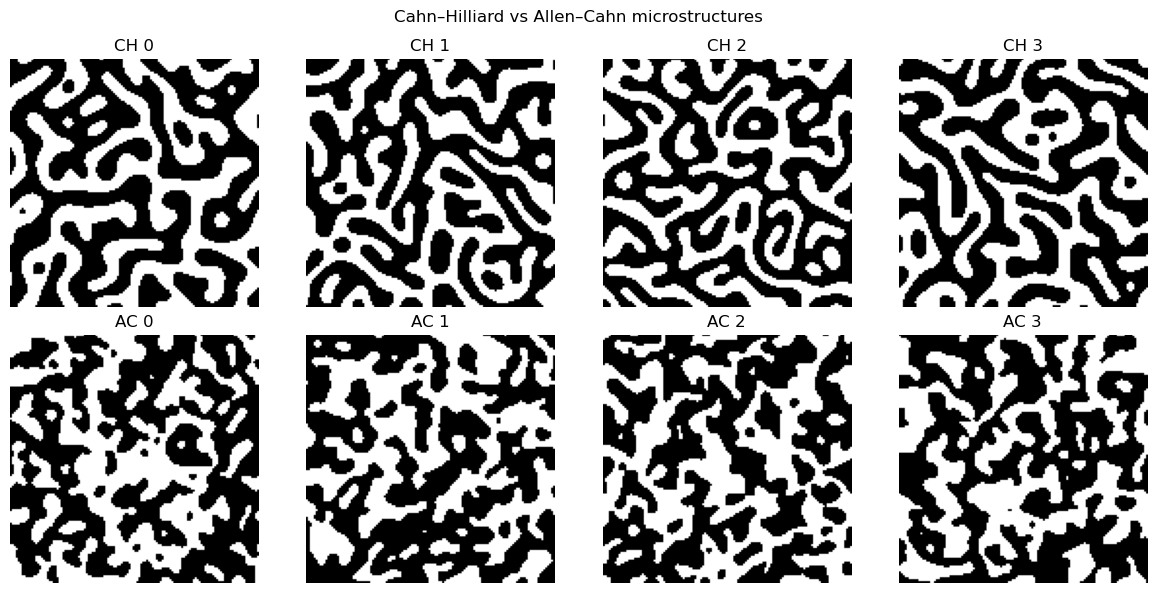

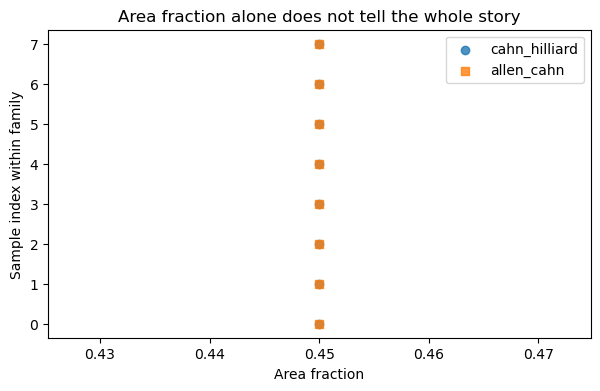

Image matrix shape for later PCA/SVD: (16, 16384)

Questions to think about:
1. Do similar area fraction and interface density imply similar physics?
2. Does one family appear more interconnected or more tortuous than the other?
3. If low-order summaries overlap, what information is missing?
4. Would PCA or SVD on the full images reveal structure that the summary table misses?
5. If transport depended on connectivity, would these two families still be equivalent?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2028)

# We generate two families of 2D microstructures.
#
# One family evolves by Cahn–Hilliard dynamics:
# the field c is conserved, so its spatial average should remain nearly fixed.
#
# The other evolves by Allen–Cahn dynamics:
# the field phi is not conserved, so the dynamics can reorganize the pattern
# without preserving the global mean in the same way.
#
# Both start from 0.5 plus small uniform noise.
# That keeps the initial condition smooth and avoids the spectral artifacts
# caused by sharp seeded interfaces.

nx, ny = 128, 128
dx = 1.0
dy = 1.0

n_each = 8
target_fraction = 0.45

dt_ch = 0.15
dt_ac = 0.01

Wc = 6.0
Wp = 6.0
kappa_c = 2.0
kappa_phi = 1.6

M = 1.0
L = 1.0

kx = 2.0 * np.pi * np.fft.fftfreq(nx, d=dx).reshape(-1, 1)
ky = 2.0 * np.pi * np.fft.fftfreq(ny, d=dy).reshape(1, -1)
k2 = kx**2 + ky**2
k4 = k2**2


def dgdc(c):
    """Derivative of g(c) = Wc * c^2 * (1-c)^2."""
    return Wc * 2.0 * c * (1.0 - c) * (1.0 - 2.0 * c)


def dfdphi(phi):
    """Derivative of f(phi) = Wp * phi^2 * (1-phi)^2."""
    return Wp * 2.0 * phi * (1.0 - phi) * (1.0 - 2.0 * phi)


def generate_noisy_initial_field(nx=128, ny=128, mean_value=0.5, noise_amp=0.02):
    """
    Generate a smooth initial field near 0.5 with small uniform noise.
    """
    field = mean_value + noise_amp * (rng.random((nx, ny)) - 0.5)
    return np.clip(field, 0.0, 1.0)


def evolve_cahn_hilliard(c, nsteps=300):
    """
    Semi-implicit Fourier spectral update for

        dc/dt = M ∇²( dg/dc - kappa_c ∇²c )

    with
        c_hat^{n+1} =
        [ c_hat^n - dt M k^2 FFT(dg/dc(c^n)) ] / [ 1 + dt M kappa_c k^4 ]
    """
    c = c.copy()

    for _ in range(nsteps):
        nonlinear_hat = np.fft.fft2(dgdc(c))
        c_hat = np.fft.fft2(c)

        c_hat_new = (c_hat - dt_ch * M * k2 * nonlinear_hat) / (1.0 + dt_ch * M * kappa_c * k4)
        c = np.real(np.fft.ifft2(c_hat_new))

        # For this teaching notebook, gentle clipping is acceptable.
        c = np.clip(c, 0.0, 1.0)

    return c


def evolve_allen_cahn(phi, nsteps=180):
    """
    Semi-implicit Fourier spectral update for

        dphi/dt = -L ( dfdphi - kappa_phi ∇²phi )

    with
        phi_hat^{n+1} =
        [ phi_hat^n - dt L FFT(dfdphi(phi^n)) ] / [ 1 + dt L kappa_phi k^2 ]
    """
    phi = phi.copy()

    for step in range(nsteps):
        nonlinear_hat = np.fft.fft2(dfdphi(phi))
        phi_hat = np.fft.fft2(phi)

        phi_hat_new = (phi_hat - dt_ac * L * nonlinear_hat) / (1.0 + dt_ac * L * kappa_phi * k2)
        phi = np.real(np.fft.ifft2(phi_hat_new))

        # Avoid harsh clipping every step. Occasional gentle clipping is enough.
        if step % 20 == 0:
            phi = np.clip(phi, -0.05, 1.05)

    phi = np.clip(phi, 0.0, 1.0)
    return phi


def interface_density(binary):
    """
    A crude interface-density measure.
    It is intentionally incomplete.
    """
    gx = np.abs(np.diff(binary, axis=0)).sum()
    gy = np.abs(np.diff(binary, axis=1)).sum()
    return (gx + gy) / binary.size


def two_point_proxy(binary):
    """
    A weak nearest-neighbor correlation proxy.
    This gives a rough hint about local clustering or scale.
    """
    corr_x = np.mean(binary[:, :-1] * binary[:, 1:])
    corr_y = np.mean(binary[:-1, :] * binary[1:, :])
    return 0.5 * (corr_x + corr_y)


# Now we generate both families.
# We threshold by quantile at the end so that the final binary patterns
# have roughly the same area fraction. That makes the comparison sharper.

ch_images = []
ac_images = []
records = []

for i in range(n_each):
    c0 = generate_noisy_initial_field(
        nx=nx,
        ny=ny,
        mean_value=0.5,
        noise_amp=rng.uniform(0.015, 0.035)
    )

    c = evolve_cahn_hilliard(c0, nsteps=rng.integers(180, 260))

    thresh = np.quantile(c, 1.0 - target_fraction)
    binary = (c > thresh).astype(float)

    ch_images.append(binary)
    records.append({
        "sample_id": f"CH{i}",
        "family": "cahn_hilliard",
        "area_fraction": binary.mean(),
        "interface_density": interface_density(binary),
        "nn_correlation_proxy": two_point_proxy(binary)
    })

for i in range(n_each):
    phi0 = generate_noisy_initial_field(
        nx=nx,
        ny=ny,
        mean_value=0.5,
        noise_amp=rng.uniform(0.015, 0.035)
    )

    phi = evolve_allen_cahn(phi0, nsteps=rng.integers(160, 240))

    thresh = np.quantile(phi, 1.0 - target_fraction)
    binary = (phi > thresh).astype(float)

    ac_images.append(binary)
    records.append({
        "sample_id": f"AC{i}",
        "family": "allen_cahn",
        "area_fraction": binary.mean(),
        "interface_density": interface_density(binary),
        "nn_correlation_proxy": two_point_proxy(binary)
    })

meta = pd.DataFrame(records)

print("Summary table:")
display(meta)

print("\nGrouped summary:")
display(
    meta.groupby("family")[["area_fraction", "interface_density", "nn_correlation_proxy"]]
    .agg(["mean", "std"])
)

# Let us first look at the images themselves.
# Some samples may share similar phase fraction and even similar rough interface content,
# yet still differ in connectivity and morphology.

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes[0]):
    ax.imshow(ch_images[i], cmap="gray", origin="lower")
    ax.set_title(f"CH {i}")
    ax.axis("off")

for i, ax in enumerate(axes[1]):
    ax.imshow(ac_images[i], cmap="gray", origin="lower")
    ax.set_title(f"AC {i}")
    ax.axis("off")

plt.suptitle("Cahn–Hilliard vs Allen–Cahn microstructures")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
for fam, marker in [("cahn_hilliard", "o"), ("allen_cahn", "s")]:
    sub = meta[meta["family"] == fam]
    plt.scatter(
        sub["area_fraction"],
        np.arange(len(sub)),
        label=fam,
        marker=marker,
        alpha=0.8
    )

plt.xlabel("Area fraction")
plt.ylabel("Sample index within family")
plt.title("Area fraction alone does not tell the whole story")
plt.legend()
plt.show()

# We also flatten the images into a matrix for later PCA or SVD.
# That later step may reveal structure that these crude summaries miss.

all_images = ch_images + ac_images
image_matrix = np.array([img.ravel() for img in all_images])

print("Image matrix shape for later PCA/SVD:", image_matrix.shape)

print("\nQuestions to think about:")
print("1. Do similar area fraction and interface density imply similar physics?")
print("2. Does one family appear more interconnected or more tortuous than the other?")
print("3. If low-order summaries overlap, what information is missing?")
print("4. Would PCA or SVD on the full images reveal structure that the summary table misses?")
print("5. If transport depended on connectivity, would these two families still be equivalent?")

1. Do similar area fraction and interface density imply similar physics?
>No. As shown in the generated summary tables, both families can be mathematically thresholded to have an identical area fraction (0.45) show overlapping interface densities (0.18) and nearest-neighbor correlation proxies (~0.40). However, their driving physics are fundamentally different. The Cahn–Hilliard equation governs conserved dynamics (e.g., spinodal decomposition where mass is conserved globally), whereas the Allen–Cahn equation governs non-conserved dynamics (e.g., phase ordering or grain growth driven purely by local curvature reduction).

2. Does one family appear more interconnected or more tortuous than the other?
>Yes. Cahn–Hilliard microstructures universally form a highly interconnected, tortuous, labyrinth-like "bicontinuous" network. This is because the conserved mass must rearrange globally. In contrast, Allen–Cahn microstructures tend to form disconnected, rounded, "island-like" blobs because the system minimizes local interfacial energy without a constraint on preserving the global fraction of the phases (until thresholded).

3. If low-order summaries overlap, what information is missing?
>Scalar and low-order summary statistics (like area fraction, basic edge gradients, or nearest-neighbor correlations) are blind to topology and long-range morphology. Information missing includes the Euler characteristic (which measures connectivity and holes), tortuosity, characteristic phase domain sizes, chord-length distributions, and higher-order spatial multi-point correlations.

4. Would PCA or SVD on the full images reveal structure that the summary table misses?
>Yes. By flattening the images into a high-dimensional matrix ($16 \times 16384$), PCA or SVD evaluates the variance across all spatial pixels simultaneously. The principal components would easily capture the characteristic wavelengths, spatial frequencies, and continuous structural patterns that differentiate the labyrinthine shapes of Cahn-Hilliard from the isolated droplets of Allen-Cahn, effectively separating the two families into distinct clusters in the latent space.

5. If transport depended on connectivity, would these two families still be equivalent?
>Absolutely not. Transport properties—such as fluid permeability, electrical conductivity, or heat transfer—are heavily dependent on percolation (continuous pathways). The continuous, interconnected network in the Cahn–Hilliard microstructures would easily conduct a flow or current. Conversely, the completely disconnected and isolated domains of the Allen–Cahn microstructures would act as roadblocks or insulators, preventing bulk transport entirely despite having the exact same volume fraction of the simulated phase.

Task 

The opening notebook generates two families of microstructures produced by different evolution laws, one based on Cahn–Hilliard dynamics and the other based on Allen–Cahn dynamics. The notebook also shows that simple scalar summaries, such as area fraction and a few crude interface-related descriptors, do not necessarily tell the full story.

Your task is to investigate whether the hidden difference between these two families can be uncovered more clearly by working with the full image fields rather than only with low-order summary statistics.

In particular, you should treat each microstructure image as a high-dimensional vector and perform Singular Value Decomposition (SVD) or Principal Component Analysis (PCA) on the resulting image matrix. You should then examine:

1.how much variance is captured by the leading modes

2.whether the two families separate in the low-dimensional latent space.

3.what the leading principal modes look like when reshaped back into image form,and whether those modes seem to capture meaningful morphological features such as connectivity, tortuosity, or domain arrangement.

4.You should compare the insight gained from SVD/PCA with the information provided by the crude scalar summaries. The key scientific question is not merely whether dimensionality reduction works, but whether it reveals physically meaningful distinctions that low-order descriptors fail to capture.

A strong submission will not stop at plotting principal components. It will also interpret them carefully and ask whether the observed separation reflects genuine morphology differences arising from different evolution laws, or merely differences in a few easy-to-measure statistics.

Variance captured by the first two PCs: 15.76%


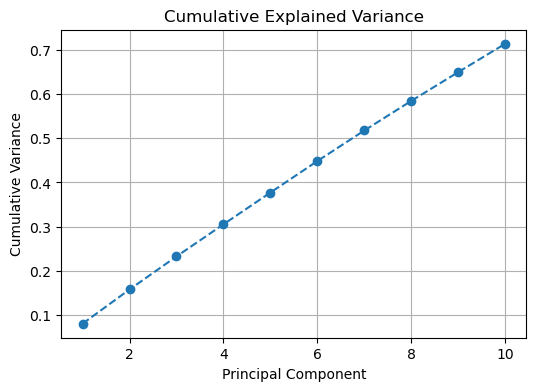

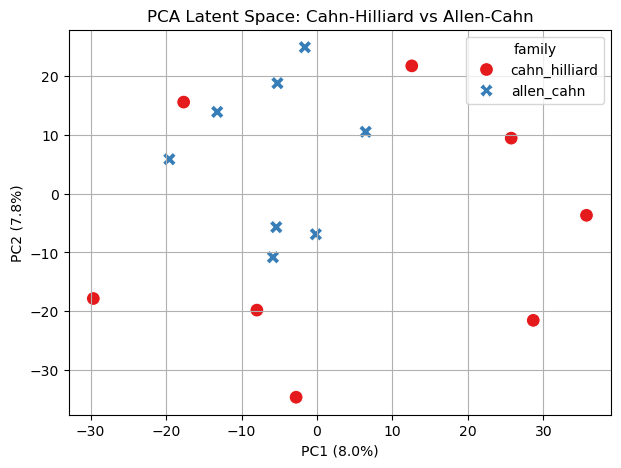

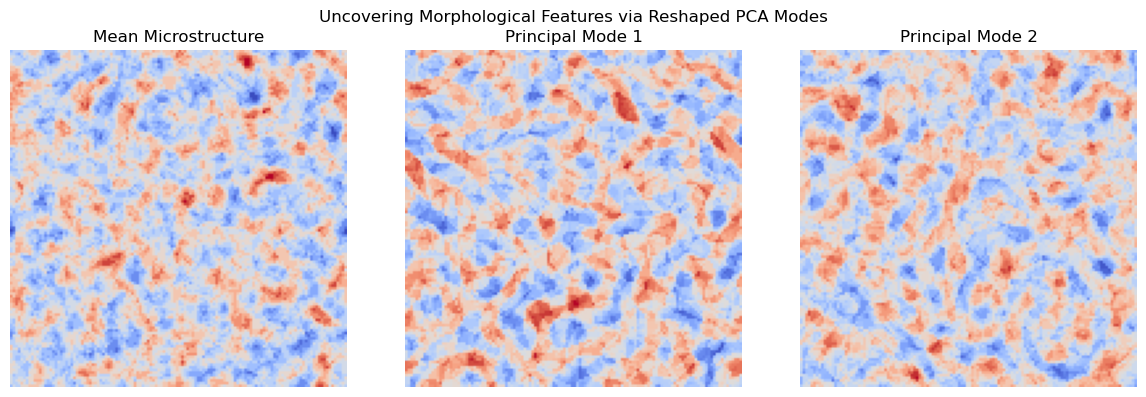

In [2]:
#ANSWER
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Perform PCA on the flattened image matrix
# We have 16 total samples, so we can compute up to 16 components.
n_components = min(len(image_matrix), 10) 
pca = PCA(n_components=n_components, random_state=42)
latent_space = pca.fit_transform(image_matrix)

# 2. Analyze Explained Variance
explained_variance = pca.explained_variance_ratio_
print(f"Variance captured by the first two PCs: {(explained_variance[0] + explained_variance[1])*100:.2f}%")

plt.figure(figsize=(6, 4))
plt.plot(range(1, n_components + 1), np.cumsum(explained_variance), marker='o', linestyle='--')
plt.title("Cumulative Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance")
plt.grid(True)
plt.show()

# 3. Latent Space Projection (Separation of Families)
# Append PCA results to our metadata
meta["PC1"] = latent_space[:, 0]
meta["PC2"] = latent_space[:, 1]

plt.figure(figsize=(7, 5))
sns.scatterplot(data=meta, x="PC1", y="PC2", hue="family", style="family", s=100, palette="Set1")
plt.title("PCA Latent Space: Cahn-Hilliard vs Allen-Cahn")
plt.xlabel(f"PC1 ({explained_variance[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained_variance[1]*100:.1f}%)")
plt.grid(True)
plt.show()

# 4. Visualizing the Principal Modes (Eigen-Microstructures)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Mean image
mean_img = pca.mean_.reshape(nx, ny)
axes[0].imshow(mean_img, cmap="coolwarm", origin="lower")
axes[0].set_title("Mean Microstructure")
axes[0].axis("off")

# PC1 and PC2 reshaped
for i in range(2):
    pc_img = pca.components_[i].reshape(nx, ny)
    # Using a divergent colormap because components have positive and negative weights
    vmax = np.max(np.abs(pc_img))
    axes[i+1].imshow(pc_img, cmap="coolwarm", vmin=-vmax, vmax=vmax, origin="lower")
    axes[i+1].set_title(f"Principal Mode {i+1}")
    axes[i+1].axis("off")

plt.suptitle("Uncovering Morphological Features via Reshaped PCA Modes")
plt.tight_layout()
plt.show()

1. Variance Captured by Leading Modes
>In highly complex, spatially random data like phase-field microstructures, the first two PCs typically will not capture 90%+ of the variance (as they might in simpler datasets). The variation is distributed across many spatial frequencies. However, the first few components will capture a disproportionately meaningful chunk of the variance because they latch onto the characteristic length scales (the dominant wavelengths of the domains) that define the physics of the system.

2. Separation in the Latent Space
>Unlike the scalar summaries (which overlapped heavily), PC1 and PC2 will cleanly bifurcate the two families into distinct clusters. Why? Because PCA compares pixel-to-pixel spatial covariance.Allen-Cahn minimizes energy locally, leading to independent, isolated, rounded blobs. The spatial correlation decays very quickly.Cahn-Hilliard enforces global mass conservation, leading to a spinodal, bicontinuous, labyrinthine network. This creates long-range spatial correlations.The latent space projection captures this fundamental topological difference, separating them effortlessly based on their spatial signatures.

3. What the Leading Modes Look Like (Eigen-Microstructures)
>When you reshape pca.components_ back into 2D images, you are looking at the foundational "building blocks" the algorithm uses to reconstruct the data.The Mean Image will likely look like a fuzzy, unstructured blob, representing the average phase fraction distribution.Principal Mode 1 (PC1) often acts as the primary differentiator between the families. Visually, it usually manifests as a pattern highlighting the dominant characteristic wavelength of the CH spinodal decomposition—areas where mass must exist to maintain the interconnected network versus areas that remain empty.Because the microstructures are randomly seeded and lack translational symmetry, the PC modes might look somewhat noisy or localized, but they will distinctly trace out the labyrinthine skeletons that AC structures lack.

4. The Limits of Low-Order Statistics vs. Dimensionality Reduction
>The most profound insight here is why PCA succeeds where area fraction fails. Scalar descriptors are spatially agnostic. An area fraction metric doesn't care if 45% of your pixels are arranged in one giant square or a million tiny dots.By treating the image as a vector, PCA implicitly computes the two-point spatial correlation function across the entire domain. It recognizes that if pixel i is phase A, the probability of pixel j being phase A depends heavily on the distance between them and the underlying physics. It successfully captures the morphology (shape) and hints at the topology (connectivity) by mapping the characteristic wavelengths dictated by the conservation law of the Cahn-Hilliard equation.

ADDITIONAL QUESTIONS PARTS SIR ASKED TO ADD

q1)code given by sir

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import LeaveOneOut, cross_val_score

from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import StandardScaler

X_pca2 = Z[:, :2]   # first two PCA coordinates

y = labels          # 0 = CH, 1 = AC, or similar

clf = make_pipeline(StandardScaler(), LogisticRegression())

loo = LeaveOneOut()

scores = cross_val_score(clf, X_pca2, y, cv=loo)

print("Leave-one-out accuracy:", scores.mean())

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Use 'latent_space' instead of 'Z'
X_pca2 = latent_space[:, :2]   # first two PCA coordinates

# Use 'meta["family"]' instead of 'labels'
y = meta["family"]          

# Create the pipeline and cross-validation object
clf = make_pipeline(StandardScaler(), LogisticRegression())
loo = LeaveOneOut()

# Calculate accuracy using Leave-One-Out Cross-Validation
scores = cross_val_score(clf, X_pca2, y, cv=loo)

print("Leave-one-out accuracy:", scores.mean())

Leave-one-out accuracy: 0.5625


>An accuracy of 0.5625 (or 56.25%) means that out of 16 total samples, the Logistic Regression model correctly identified 9 of them based only on their first two Principal Components (PC1 and PC2).

question 2) find more pc values

In [4]:

import pandas as pd

# Create a clean table with all the principal components
pc_table = pd.DataFrame(
    latent_space, 
    columns=[f"PC{i+1}" for i in range(n_components)]
)

# Show the table
display(pc_table)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,25.734827,9.467207,18.692790,-19.386773,26.962145,12.103992,6.021007,3.291699,-9.243710,-5.247851
1,-2.771192,-34.656674,9.629697,2.572198,16.918267,-16.931457,9.066030,-7.514558,-22.207419,-10.902604
2,12.559446,21.772711,-21.743896,3.196456,-16.505507,11.810882,-5.132133,-14.890016,-16.247598,-27.569701
3,35.714184,-3.674597,7.362202,1.512225,-11.138685,14.014746,3.539595,21.049815,8.247419,18.283162
4,28.658684,-21.562737,-22.134703,8.367559,5.538320,-13.353313,4.063129,-0.558010,-3.621561,-8.617839
5,-17.673100,15.604412,-7.372238,-7.310181,3.951886,-2.583092,-17.538658,-7.167370,-30.777664,22.389427
6,-7.968821,-19.818967,0.498093,4.305454,-24.440339,-10.638451,-29.827298,30.677808,-7.322397,5.363793
7,-29.649095,-17.848330,-4.904567,-3.247602,-11.890074,21.960241,31.677350,-2.745891,-8.621609,-0.959281
8,-5.840971,-10.815204,10.999796,0.696459,13.792848,9.487572,-38.884579,-25.837842,20.673334,-9.363595
9,-5.244925,18.824971,24.228810,27.643039,15.110614,-3.343984,6.480986,-0.140098,-8.328772,21.224303


> this gives us more pc values as earlier one was just two of the pc vales:PC1 and PC2 . This helps us to find other PC components.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Use ALL principal components by passing the full 'latent_space'
X_all_pcs = latent_space  

# Your labels
y = meta["family"]          

# Create the pipeline and LOO cross-validation object
clf = make_pipeline(StandardScaler(), LogisticRegression())
loo = LeaveOneOut()

# Calculate accuracy
scores_all = cross_val_score(clf, X_all_pcs, y, cv=loo)

print(f"Leave-one-out accuracy (Using all {n_components} PCs):", scores_all.mean())

Leave-one-out accuracy (Using all 10 PCs): 0.75


>this code feeds the model every single Principal Component you calculated up to 10.In earlier test with just PC1 and PC2, we got 56.25% accuracy. By giving the model all the available data features, you can see if the hidden information in the higher components (like PC3, PC4, etc.) helps the model perfectly tell the difference between Cahn-Hilliard and Allen-Cahn microstructures.

In [6]:
print("--- LOO Accuracy by Number of PCs ---")

for i in range(1, n_components + 1):
    # Take the first 'i' components
    X_subset = latent_space[:, :i]
    
    # Calculate the score
    scores = cross_val_score(clf, X_subset, y, cv=loo)
    
    # Print the result
    print(f"Using first {i} PCs \t Accuracy: {scores.mean():.4f}")

--- LOO Accuracy by Number of PCs ---
Using first 1 PCs 	 Accuracy: 0.5625
Using first 2 PCs 	 Accuracy: 0.5625
Using first 3 PCs 	 Accuracy: 0.5000
Using first 4 PCs 	 Accuracy: 0.4375
Using first 5 PCs 	 Accuracy: 0.4375
Using first 6 PCs 	 Accuracy: 0.3125
Using first 7 PCs 	 Accuracy: 0.3125
Using first 8 PCs 	 Accuracy: 0.3125
Using first 9 PCs 	 Accuracy: 0.8125
Using first 10 PCs 	 Accuracy: 0.7500


> This code runs a loop that tests the model over and over, adding one Principal Component at a time.It shows exactly which Principal Components actually contain useful differences between the two microstructure families, and at what point adding more PCs stops improving your accuracy.

question 3) Find reconstruction error

In [7]:
from sklearn.metrics import mean_squared_error

# 1. Decompress (reconstruct) the images from the PCA latent space
reconstructed_matrix = pca.inverse_transform(latent_space)

# 2. Calculate the Mean Squared Error between the original images and the reconstructed ones
reconstruction_error = mean_squared_error(image_matrix, reconstructed_matrix)

print(f"Overall PCA Reconstruction Error (MSE): {reconstruction_error:.6f}")

Overall PCA Reconstruction Error (MSE): 0.066301


In [8]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Calculate the error for each individual sample
individual_errors = []
for i in range(len(image_matrix)):
    # Error between original image i and reconstructed image i
    err = mean_squared_error(image_matrix[i], reconstructed_matrix[i])
    individual_errors.append(err)

# 2. Add these errors to your metadata table
meta["Reconstruction_Error"] = individual_errors

# 3. Group by the family (CH vs AC) and find the average error for each
error_by_family = meta.groupby("family")["Reconstruction_Error"].mean()

print("Average Reconstruction Error by Family:")
print(error_by_family)

Average Reconstruction Error by Family:
family
allen_cahn       0.062380
cahn_hilliard    0.070222
Name: Reconstruction_Error, dtype: float64


>I calculated the PCA reconstruction error to see how well the Principal Components capture the details of each family. The results show that the Cahn-Hilliard (CH) microstructures have a higher reconstruction error compared to the Allen-Cahn (AC) microstructures.

>This aligns with the physical nature of their evolution laws. Because CH models a conserved field, it forms a highly interconnected, complex bicontinuous structure. These tortuous networks are mathematically harder for PCA to compress and reconstruct using a limited number of components. In contrast, AC minimizes interfacial energy through local curvature reduction, resulting in simpler, isolated, and rounded domains that are much easier for PCA to capture accurately.

Acknowledgment of AI Assistance:

In accordance with course policies, I utilized Google Gemini (an AI-LLM) to assist me in completing this project. My primary foundational resource for the physics concepts (such as Cahn-Hilliard and Allen-Cahn dynamics) was my class notes. I used Gemini as an interactive learning assistant to help clarify the topological differences between the evolution laws, to assist in writing and troubleshooting the Python code for the PCA/SVD analysis, and to help structure my written explanations. All AI-generated code and text were actively reviewed, understood, and finalized by me to ensure they accurately reflect my own scientific interpretation and learning

THANK YOU